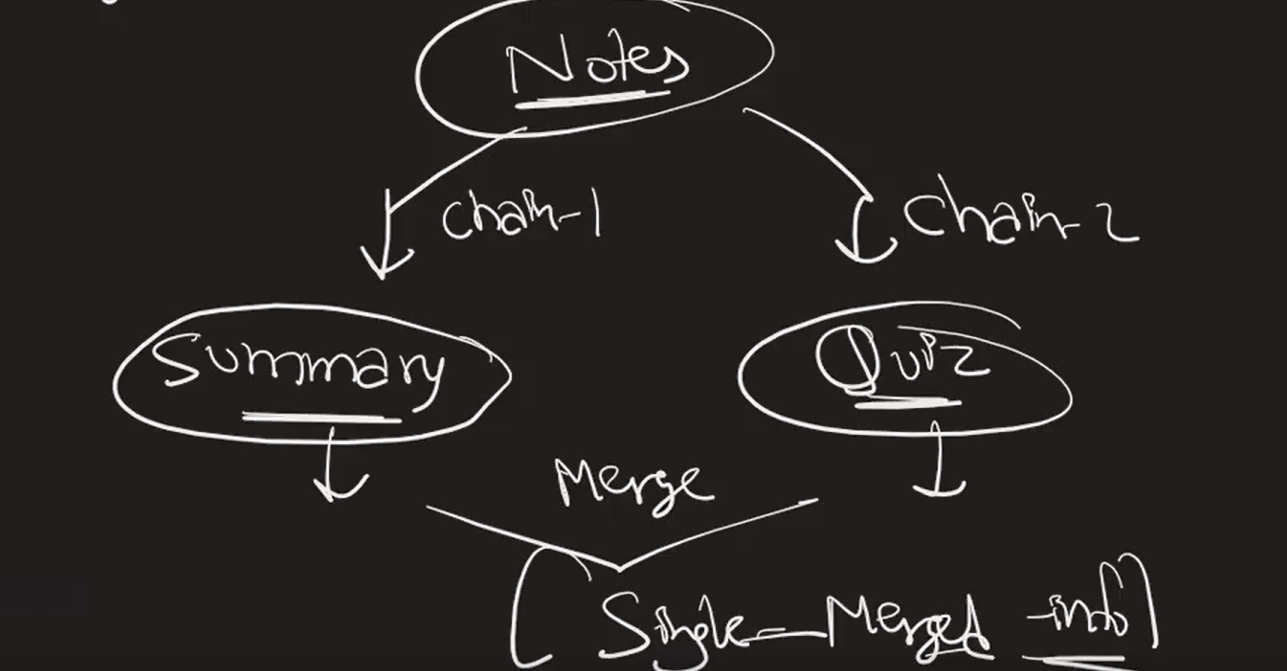

In [1]:
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_ollama import ChatOllama
from langchain_core.runnables import RunnableParallel
from langchain_core.output_parsers import StrOutputParser

In [2]:
load_dotenv()

True

In [3]:
llama = ChatOllama(model='llama3.1:8b',temperature=0.5)
gemini = ChatGoogleGenerativeAI(model='gemini-3.5-flash-lite',temperature=0.5)

In [4]:
llama_prompt = PromptTemplate(template='Generate a Summary on this topic {Topic}',
                              input_variables=['Topic'])
gemini_prompt = PromptTemplate(template='Generate 5 quiz questions on this topic {Topic}', input_variables=['Topic'])

In [5]:
parser = StrOutputParser()

In [7]:
parallel_chain = RunnableParallel({'Summary':llama_prompt | llama | parser, 'Quiz':gemini_prompt | gemini | parser})

In [19]:
merge_prompt = PromptTemplate(template='Merge the following {Summary} and {Quiz} together', input_variables=['Summary','Quiz'])

In [20]:
merge_chain = merge_prompt | gemini | parser

In [21]:
final_chain = parallel_chain | merge_chain

In [22]:
response = final_chain.invoke({'Topic':'Cricket'})

In [24]:
response

"Here is the complete guide to cricket, featuring a comprehensive summary of the sport followed by a trivia quiz to test your knowledge.\n\n---\n\n# **The Ultimate Guide to Cricket: Summary & Quiz**\n\n## **Part 1: Summary of Cricket**\n\n**What is Cricket?**  \nCricket is a popular team sport played with a bat and ball between two teams, each consisting of 11 players. The game originated in England in the 16th century and has since become one of the most widely watched and played sports globally, boasting over 2.5 billion fans. It is played and watched extensively in countries such as India, Australia, England, Pakistan, South Africa, and the West Indies.\n\n**Objective:**  \nThe objective of cricket is to score runs by hitting the ball with a bat while the opposing team tries to stop them by getting the batsmen out. A match typically consists of innings, with each team batting and bowling in turn.\n\n**Key Positions:**  \n1. **Batsman:** The player who hits the ball with a bat.  \n2.

In [ ]:
'''
find the duplicate element in a string and the frequency
input: "Application"
output:
a-2
p-2
i-2
'''

